In [55]:
# Install + Imports

!pip -q install grad-cam

import os
import random
import zipfile
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Dataset
from torchvision import datasets, transforms, models

from sklearn.metrics import accuracy_score
import shutil
import cv2

# GradCAM
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [56]:
# Reproducibility

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

In [57]:
# Utility Functions

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def train_model(model, train_loader, val_loader, epochs=10, lr=1e-3):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc = evaluate(model, val_loader, criterion)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"Epoch [{epoch+1}/{epochs}] "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    return history

def plot_history(history, title_prefix="Model"):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(7,5))
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title_prefix} Loss Curve")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(7,5))
    plt.plot(epochs, history["train_acc"], label="Train Accuracy")
    plt.plot(epochs, history["val_acc"], label="Val Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title_prefix} Accuracy Curve")
    plt.legend()
    plt.grid(True)
    plt.show()

In [58]:
# Custom CNN

class CustomCNN(nn.Module):
    def __init__(self, in_channels=1, num_classes=10):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 16, kernel_size=3, padding=1),   # 28x28 -> 28x28
            nn.ReLU(),
            nn.MaxPool2d(2),                                        # 28x28 -> 14x14

            nn.Conv2d(16, 32, kernel_size=3, padding=1),            # 14x14 -> 14x14
            nn.ReLU(),
            nn.MaxPool2d(2),                                        # 14x14 -> 7x7

            nn.Conv2d(32, 32, kernel_size=3, padding=1),            # 7x7 -> 7x7
            nn.ReLU(),
            nn.MaxPool2d(2)                                         # 7x7 -> 3x3
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 3 * 3, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

mnist_model = CustomCNN(in_channels=1, num_classes=10)
print("Trainable params:", count_parameters(mnist_model))
assert count_parameters(mnist_model) < 50000, "Parameter count exceeds 50,000!"

Trainable params: 33194


In [59]:
# Load Standard MNIST

mnist_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

full_train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=mnist_transform)
test_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=mnist_transform)

train_size = int(0.9 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=2, pin_memory=True)

print("Train:", len(train_dataset), "Val:", len(val_dataset), "Test:", len(test_dataset))

Train: 54000 Val: 6000 Test: 10000


Epoch [1/10] Train Loss: 0.3197, Train Acc: 0.9007 | Val Loss: 0.1042, Val Acc: 0.9692
Epoch [2/10] Train Loss: 0.0801, Train Acc: 0.9754 | Val Loss: 0.0761, Val Acc: 0.9778
Epoch [3/10] Train Loss: 0.0573, Train Acc: 0.9818 | Val Loss: 0.0560, Val Acc: 0.9832
Epoch [4/10] Train Loss: 0.0449, Train Acc: 0.9858 | Val Loss: 0.0587, Val Acc: 0.9817
Epoch [5/10] Train Loss: 0.0372, Train Acc: 0.9877 | Val Loss: 0.0524, Val Acc: 0.9843
Epoch [6/10] Train Loss: 0.0322, Train Acc: 0.9898 | Val Loss: 0.0459, Val Acc: 0.9858
Epoch [7/10] Train Loss: 0.0268, Train Acc: 0.9911 | Val Loss: 0.0450, Val Acc: 0.9863
Epoch [8/10] Train Loss: 0.0231, Train Acc: 0.9923 | Val Loss: 0.0408, Val Acc: 0.9875
Epoch [9/10] Train Loss: 0.0228, Train Acc: 0.9929 | Val Loss: 0.0420, Val Acc: 0.9882
Epoch [10/10] Train Loss: 0.0175, Train Acc: 0.9946 | Val Loss: 0.0364, Val Acc: 0.9898


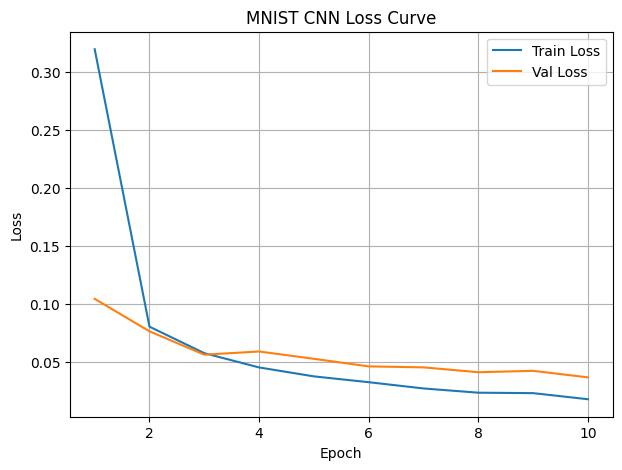

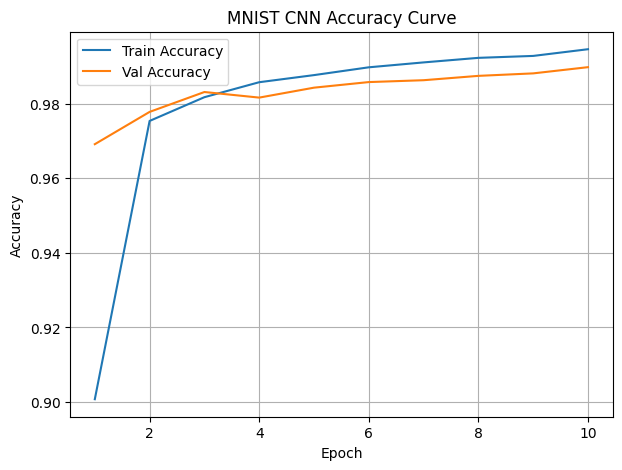

In [60]:
# Cell 6: Train on Standard MNIST

mnist_model = CustomCNN(in_channels=1, num_classes=10).to(device)

history_mnist = train_model(
    model=mnist_model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=10,
    lr=1e-3
)

plot_history(history_mnist, title_prefix="MNIST CNN")

In [61]:
# Cell 7: Final Test Accuracy

criterion = nn.CrossEntropyLoss()
test_loss, test_acc = evaluate(mnist_model, test_loader, criterion)

print(f"MNIST Test Loss: {test_loss:.4f}")
print(f"MNIST Test Accuracy: {test_acc*100:.2f}%")

MNIST Test Loss: 0.0277
MNIST Test Accuracy: 99.16%


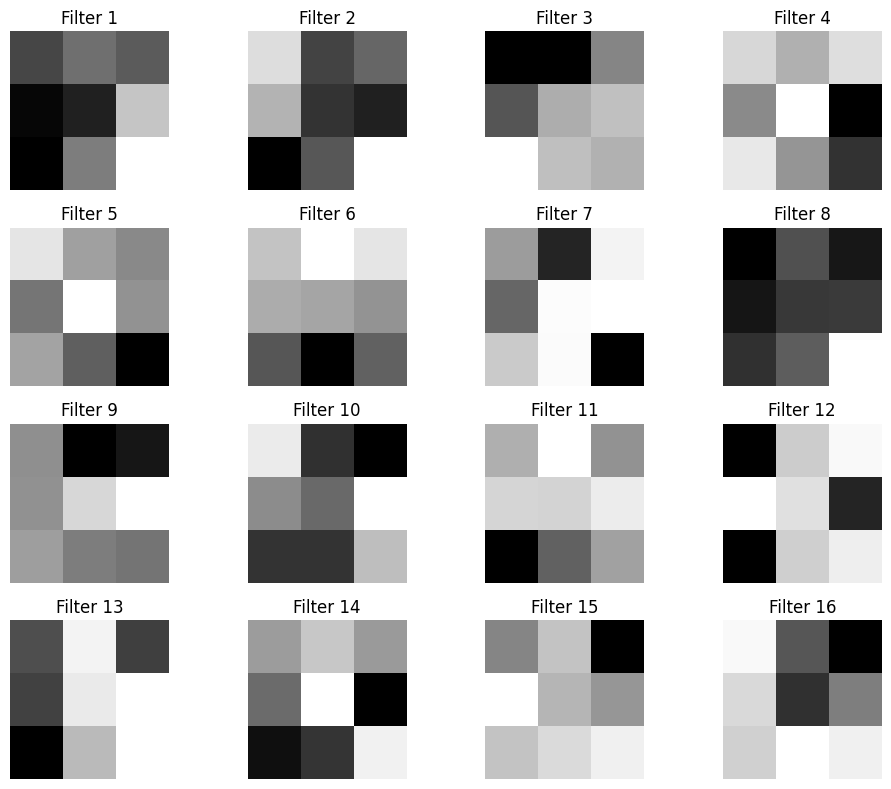

In [62]:
# Cell 8: Visualize First Conv Filters

#Analytical Question 1.2

first_conv_weights = mnist_model.features[0].weight.data.cpu()  # shape: [16, 1, 3, 3]

num_filters = first_conv_weights.shape[0]
cols = 4
rows = (num_filters + cols - 1) // cols

plt.figure(figsize=(10, 8))
for i in range(num_filters):
    plt.subplot(rows, cols, i + 1)
    filt = first_conv_weights[i, 0]
    plt.imshow(filt, cmap="gray")
    plt.title(f"Filter {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

Colored-MNIST Dataset Loader

In [63]:
# Cell 9: Extract C-MNIST

# using Google Drive
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [64]:
# Correct Google Drive paths
train_path = '/content/drive/MyDrive/cmnist/train_biased.pt'
biased_test_path = '/content/drive/MyDrive/cmnist/test_biased.pt'
unbiased_test_path = '/content/drive/MyDrive/cmnist/test_unbiased.pt'

cmnist_transform = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

class CMNISTDataset(Dataset):
    def __init__(self, data, transform=None):
        self.transform = transform

        # Handle different possible .pt formats
        if isinstance(data, dict):
            if 'images' in data and 'labels' in data:
                self.images = data['images']
                self.labels = data['labels']
            elif 'x' in data and 'y' in data:
                self.images = data['x']
                self.labels = data['y']
            else:
                raise ValueError("Unsupported dict format in .pt file")

        elif isinstance(data, (list, tuple)):
            if len(data) == 2:
                self.images, self.labels = data
            else:
                raise ValueError("Unsupported tuple/list format in .pt file")

        else:
            raise ValueError("Unsupported .pt file structure")

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img = self.images[idx]
        label = self.labels[idx]

        # Convert tensor image to PIL
        if torch.is_tensor(img):
            img = img.cpu()

            # If shape is (C,H,W), convert to (H,W,C)
            if img.ndim == 3 and img.shape[0] in [1, 3]:
                img = img.permute(1, 2, 0).numpy()
            else:
                img = img.numpy()

        if isinstance(img, np.ndarray):
            if img.dtype != np.uint8:
                # Scale to uint8 if needed
                if img.max() <= 1.0:
                    img = (img * 255).astype(np.uint8)
                else:
                    img = img.astype(np.uint8)

            if img.ndim == 2:
                img = Image.fromarray(img, mode='L').convert('RGB')
            else:
                img = Image.fromarray(img).convert('RGB')

        if self.transform:
            img = self.transform(img)

        return img, int(label)

# Load .pt files
train_data = torch.load(train_path)
biased_test_data = torch.load(biased_test_path)
unbiased_test_data = torch.load(unbiased_test_path)

# Create datasets
train_full_cmnist = CMNISTDataset(train_data, transform=cmnist_transform)
biased_test_dataset = CMNISTDataset(biased_test_data, transform=cmnist_transform)
unbiased_test_dataset = CMNISTDataset(unbiased_test_data, transform=cmnist_transform)

# Split train/val
train_size = int(0.9 * len(train_full_cmnist))
val_size = len(train_full_cmnist) - train_size

train_cmnist, val_cmnist = random_split(
    train_full_cmnist,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

# DataLoaders
train_cmnist_loader = DataLoader(train_cmnist, batch_size=128, shuffle=True, num_workers=2)
val_cmnist_loader = DataLoader(val_cmnist, batch_size=128, shuffle=False, num_workers=2)
biased_test_loader = DataLoader(biased_test_dataset, batch_size=128, shuffle=False, num_workers=2)
unbiased_test_loader = DataLoader(unbiased_test_dataset, batch_size=128, shuffle=False, num_workers=2)

print("C-MNIST Train:", len(train_cmnist))
print("C-MNIST Val:", len(val_cmnist))
print("Biased Test:", len(biased_test_dataset))
print("Unbiased Test:", len(unbiased_test_dataset))

C-MNIST Train: 54000
C-MNIST Val: 6000
Biased Test: 10000
Unbiased Test: 10000


Trainable params: 33482
Epoch [1/5] Train Loss: 0.3419, Train Acc: 0.9102 | Val Loss: 0.1325, Val Acc: 0.9630
Epoch [2/5] Train Loss: 0.0831, Train Acc: 0.9755 | Val Loss: 0.0592, Val Acc: 0.9833
Epoch [3/5] Train Loss: 0.0517, Train Acc: 0.9846 | Val Loss: 0.0434, Val Acc: 0.9882
Epoch [4/5] Train Loss: 0.0347, Train Acc: 0.9885 | Val Loss: 0.0378, Val Acc: 0.9898
Epoch [5/5] Train Loss: 0.0296, Train Acc: 0.9907 | Val Loss: 0.0371, Val Acc: 0.9893


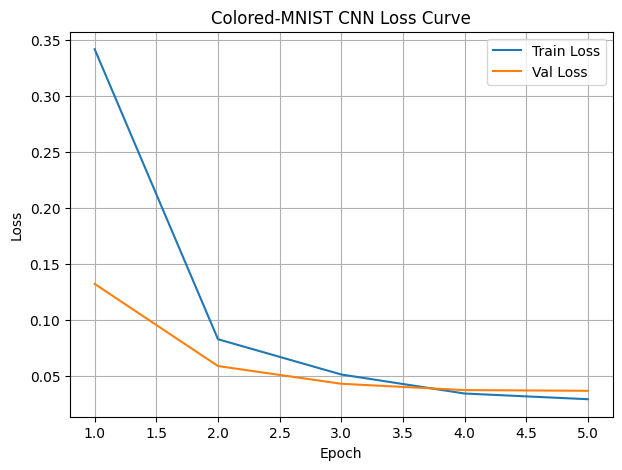

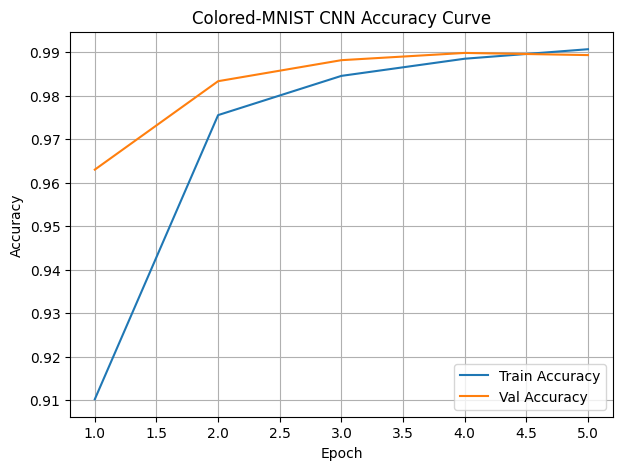

In [65]:
# Cell 11: Train RGB CNN on C-MNIST

cmnist_model = CustomCNN(in_channels=3, num_classes=10).to(device)
print("Trainable params:", count_parameters(cmnist_model))

history_cmnist = train_model(
    model=cmnist_model,
    train_loader=train_cmnist_loader,
    val_loader=val_cmnist_loader,
    epochs=5,
    lr=1e-3
)

plot_history(history_cmnist, title_prefix="Colored-MNIST CNN")

In [66]:
# Cell 12: Evaluate C-MNIST

criterion = nn.CrossEntropyLoss()

biased_loss, biased_acc = evaluate(cmnist_model, biased_test_loader, criterion)
unbiased_loss, unbiased_acc = evaluate(cmnist_model, unbiased_test_loader, criterion)

print(f"Biased Test Accuracy: {biased_acc * 100:.2f}%")
print(f"Unbiased Test Accuracy: {unbiased_acc * 100:.2f}%")
print(f"Accuracy Drop: {(biased_acc - unbiased_acc) * 100:.2f}%")

Biased Test Accuracy: 98.94%
Unbiased Test Accuracy: 87.98%
Accuracy Drop: 10.96%


Task 2 — Transfer Learning and Interpretability

In [67]:
# Load STL-10

stl_train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

stl_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

stl_train_dataset = datasets.STL10(root="./data", split="train", download=True, transform=stl_train_transform)
stl_test_dataset = datasets.STL10(root="./data", split="test", download=True, transform=stl_test_transform)

# Create validation split from train set
train_size = int(0.9 * len(stl_train_dataset))
val_size = len(stl_train_dataset) - train_size

stl_train, stl_val = random_split(
    stl_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

stl_train_loader = DataLoader(stl_train, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
stl_val_loader = DataLoader(stl_val, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)
stl_test_loader = DataLoader(stl_test_dataset, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

print("STL-10 Train:", len(stl_train))
print("STL-10 Val:", len(stl_val))
print("STL-10 Test:", len(stl_test_dataset))

STL-10 Train: 4500
STL-10 Val: 500
STL-10 Test: 8000


In [68]:
# ResNet-18 Transfer Learning

weights = models.ResNet18_Weights.DEFAULT
resnet18 = models.resnet18(weights=weights)

# Freeze backbone
for param in resnet18.parameters():
    param.requires_grad = False

# Replace final fully connected layer
num_features = resnet18.fc.in_features
resnet18.fc = nn.Linear(num_features, 10)

resnet18 = resnet18.to(device)

print("Trainable params:", count_parameters(resnet18))
print("Only FC should be trainable:")
for name, param in resnet18.named_parameters():
    if param.requires_grad:
        print(name, param.shape)

Trainable params: 5130
Only FC should be trainable:
fc.weight torch.Size([10, 512])
fc.bias torch.Size([10])


In [69]:
# Ensure all layers require gradients

for param in resnet18.parameters():
    param.requires_grad = True

for name, param in resnet18.named_parameters():
    print(f"Layer: {name}, requires_grad: {param.requires_grad}")

Layer: conv1.weight, requires_grad: True
Layer: bn1.weight, requires_grad: True
Layer: bn1.bias, requires_grad: True
Layer: layer1.0.conv1.weight, requires_grad: True
Layer: layer1.0.bn1.weight, requires_grad: True
Layer: layer1.0.bn1.bias, requires_grad: True
Layer: layer1.0.conv2.weight, requires_grad: True
Layer: layer1.0.bn2.weight, requires_grad: True
Layer: layer1.0.bn2.bias, requires_grad: True
Layer: layer1.1.conv1.weight, requires_grad: True
Layer: layer1.1.bn1.weight, requires_grad: True
Layer: layer1.1.bn1.bias, requires_grad: True
Layer: layer1.1.conv2.weight, requires_grad: True
Layer: layer1.1.bn2.weight, requires_grad: True
Layer: layer1.1.bn2.bias, requires_grad: True
Layer: layer2.0.conv1.weight, requires_grad: True
Layer: layer2.0.bn1.weight, requires_grad: True
Layer: layer2.0.bn1.bias, requires_grad: True
Layer: layer2.0.conv2.weight, requires_grad: True
Layer: layer2.0.bn2.weight, requires_grad: True
Layer: layer2.0.bn2.bias, requires_grad: True
Layer: layer2.0.dow

Epoch [1/8] Train Loss: 0.6605, Train Acc: 0.7722 | Val Loss: 0.8469, Val Acc: 0.7420
Epoch [2/8] Train Loss: 0.4118, Train Acc: 0.8553 | Val Loss: 0.5757, Val Acc: 0.8160
Epoch [3/8] Train Loss: 0.3013, Train Acc: 0.8973 | Val Loss: 1.0454, Val Acc: 0.7340
Epoch [4/8] Train Loss: 0.2428, Train Acc: 0.9151 | Val Loss: 0.5674, Val Acc: 0.8180
Epoch [5/8] Train Loss: 0.1795, Train Acc: 0.9371 | Val Loss: 0.6011, Val Acc: 0.8180
Epoch [6/8] Train Loss: 0.1587, Train Acc: 0.9476 | Val Loss: 0.4937, Val Acc: 0.8440
Epoch [7/8] Train Loss: 0.1521, Train Acc: 0.9498 | Val Loss: 0.5483, Val Acc: 0.8320
Epoch [8/8] Train Loss: 0.1439, Train Acc: 0.9487 | Val Loss: 0.5756, Val Acc: 0.8380


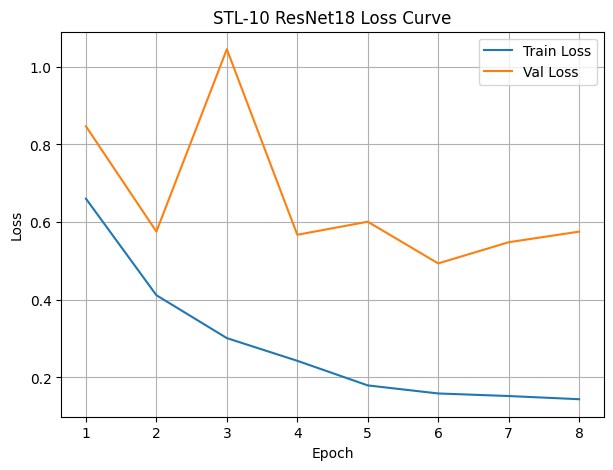

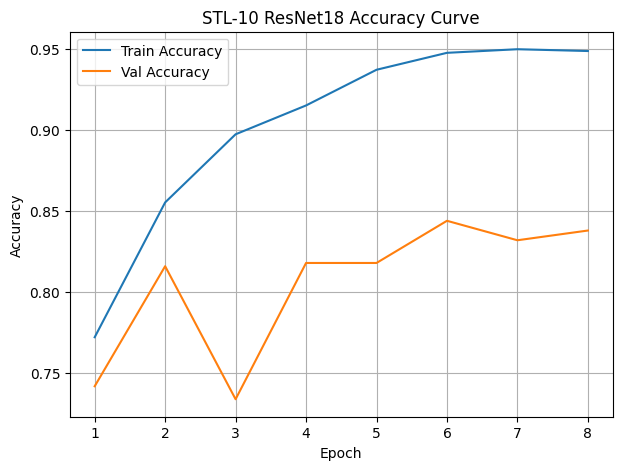

In [70]:
# Train ResNet-18 Head

history_stl = train_model(
    model=resnet18,
    train_loader=stl_train_loader,
    val_loader=stl_val_loader,
    epochs=8,
    lr=1e-3
)

plot_history(history_stl, title_prefix="STL-10 ResNet18")

In [71]:
# Evaluate STL-10

criterion = nn.CrossEntropyLoss()
stl_test_loss, stl_test_acc = evaluate(resnet18, stl_test_loader, criterion)

print(f"STL-10 Test Loss: {stl_test_loss:.4f}")
print(f"STL-10 Test Accuracy: {stl_test_acc * 100:.2f}%")

STL-10 Test Loss: 0.5084
STL-10 Test Accuracy: 85.25%


In [72]:
# STL-10 Class Names

stl_classes = ['airplane', 'bird', 'car', 'cat', 'deer',
               'dog', 'horse', 'monkey', 'ship', 'truck']
print(stl_classes)

['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']


In [73]:
# Select 2 Correct + 2 Incorrect

@torch.no_grad()
def collect_correct_incorrect(model, dataset, num_correct=2, num_incorrect=2):
    model.eval()
    correct_samples = []
    incorrect_samples = []

    for i in range(len(dataset)):
        image, label = dataset[i]
        input_tensor = image.unsqueeze(0).to(device)

        output = model(input_tensor)
        pred = output.argmax(dim=1).item()

        item = {
            "image": image,
            "label": label,
            "pred": pred,
            "index": i
        }

        if pred == label and len(correct_samples) < num_correct:
            correct_samples.append(item)
        elif pred != label and len(incorrect_samples) < num_incorrect:
            incorrect_samples.append(item)

        if len(correct_samples) == num_correct and len(incorrect_samples) == num_incorrect:
            break

    return correct_samples, incorrect_samples

correct_samples, incorrect_samples = collect_correct_incorrect(resnet18, stl_test_dataset)
print("Correct found:", len(correct_samples))
print("Incorrect found:", len(incorrect_samples))

Correct found: 2
Incorrect found: 2


=== Correct Predictions ===


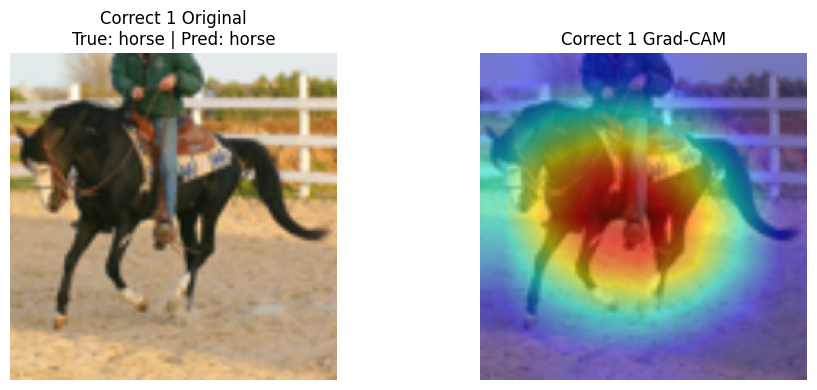

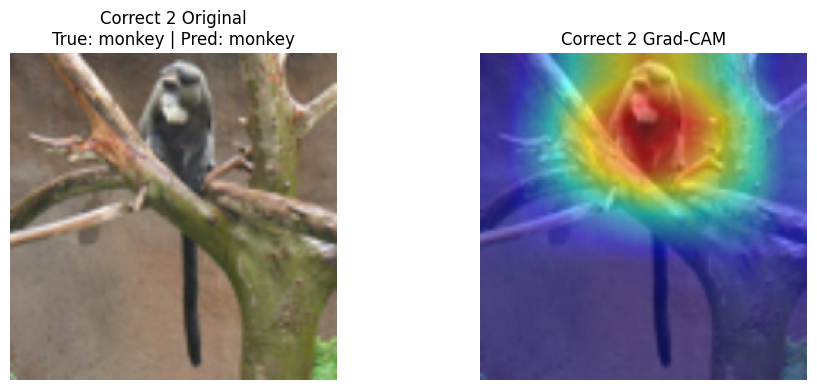

=== Incorrect Predictions ===


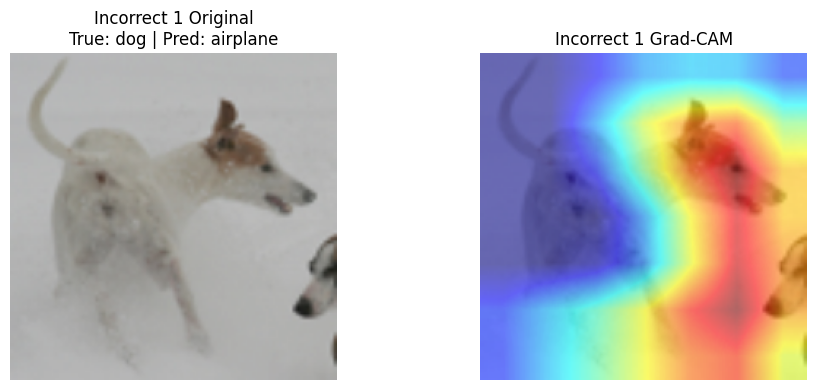

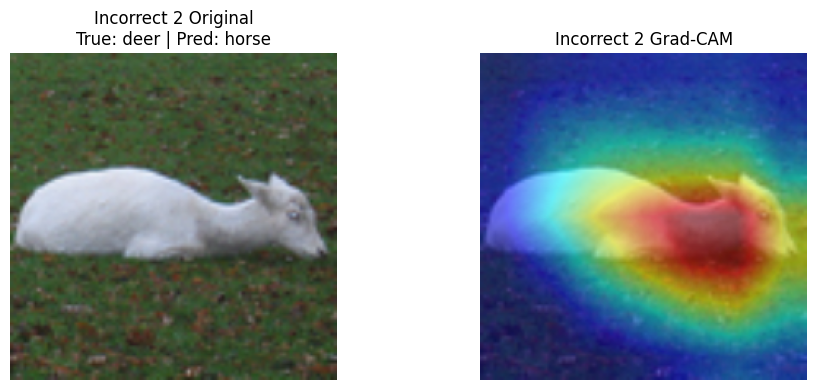

In [74]:
# Ensure model is in eval mode
resnet18.eval()

# GradCAM Setup
target_layers = [resnet18.layer4[1].conv2]  # Last convolutional layer
cam = GradCAM(model=resnet18, target_layers=target_layers)

# Inverse normalization for display
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

def denormalize(img_tensor):
    img = img_tensor.cpu().numpy().transpose(1, 2, 0)
    img = std * img + mean
    img = np.clip(img, 0, 1)
    return img

def show_gradcam(sample, title_prefix=""):
    image = sample["image"]
    label = sample["label"]
    pred = sample["pred"]

    # Ensure the input is on the correct device
    input_tensor = image.unsqueeze(0).to(device)
    targets = [ClassifierOutputTarget(pred)]

    # Generate Grad-CAM
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]

    if grayscale_cam is None:
        print(f"GradCAM returned None for prediction {pred}!")
        return

    # Denormalize image for proper visualization
    rgb_img = denormalize(image)

    # Apply Grad-CAM to the image
    visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

    # Upscale the Grad-CAM result to match the original image size
    original_image_size = rgb_img.shape[:2]
    visualization_resized = cv2.resize(visualization, (original_image_size[1], original_image_size[0]))

    plt.figure(figsize=(10, 4))

    # Original Image
    plt.subplot(1, 2, 1)
    plt.imshow(rgb_img)
    plt.title(f"{title_prefix} Original\nTrue: {stl_classes[label]} | Pred: {stl_classes[pred]}")
    plt.axis("off")

    # Grad-CAM Visualization
    plt.subplot(1, 2, 2)
    plt.imshow(visualization_resized)
    plt.title(f"{title_prefix} Grad-CAM")
    plt.axis("off")

    plt.tight_layout()
    plt.show()


print("=== Correct Predictions ===")
for i, sample in enumerate(correct_samples, 1):
    show_gradcam(sample, title_prefix=f"Correct {i}")

print("=== Incorrect Predictions ===")
for i, sample in enumerate(incorrect_samples, 1):
    show_gradcam(sample, title_prefix=f"Incorrect {i}")

In [75]:
# Cell 21: Save Results for Report

os.makedirs("results", exist_ok=True)

def save_history_plot(history, filename_prefix):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(7,5))
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{filename_prefix} Loss")
    plt.legend()
    plt.grid(True)
    plt.savefig(f"results/{filename_prefix}_loss.png", bbox_inches="tight")
    plt.close()

    plt.figure(figsize=(7,5))
    plt.plot(epochs, history["train_acc"], label="Train Accuracy")
    plt.plot(epochs, history["val_acc"], label="Val Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{filename_prefix} Accuracy")
    plt.legend()
    plt.grid(True)
    plt.savefig(f"results/{filename_prefix}_accuracy.png", bbox_inches="tight")
    plt.close()

save_history_plot(history_mnist, "mnist")
save_history_plot(history_cmnist, "cmnist")
save_history_plot(history_stl, "stl10_resnet18")

print("Plots saved in results/")

Plots saved in results/


In [76]:
# zip file
results_dir = "results"
zip_file = "results.zip"

shutil.make_archive(zip_file, 'zip', results_dir)

print(f"Results have been successfully zipped as {zip_file}")

Results have been successfully zipped as results.zip
